# Ejercicio 4. Análisis exploratorio con DuckDB

Las consultas están en `sql/02_eda.sql` y usan las vistas de `sql/00_vistas.sql`. La vista `viajes` une amarillos y verdes con nombres comunes y `viajes_validos` aplica los filtros definidos en el Ejercicio 3. DuckDB hace todo el cálculo y a pandas solo llegan los resultados agregados.

Este notebook se ejecutó con los datos de 2026 (enero a agosto).

In [1]:
import sys
sys.path.append("../scripts")

import matplotlib.pyplot as plt
import pandas as pd
from consultas import cargar_consultas, conectar, ejecutar
from graficas import COLORES, NOMBRES, miles

pd.set_option("display.max_columns", 30)
con = conectar()
q = cargar_consultas("02_eda.sql")

## 4.1 Preguntas

**P1. Comportamiento temporal.** ¿Cómo cambia la demanda entre meses y en qué horas y días se concentra?

**P2. Características de los viajes.** ¿Cómo es un viaje típico en distancia, duración, velocidad y pasajeros?

**P3. Amarillos contra verdes.** ¿Operan en las mismas zonas y en los mismos horarios?

**P4. Pago.** ¿Cómo pagan los pasajeros, cuánta propina dejan y qué compone el cobro?

**P5. Distribución y atípicos.** ¿Cómo se distribuye el monto total y cuántos viajes se salen de lo normal?

Se eligieron porque cubren las columnas con más información (fechas, distancias, zonas, montos y forma de pago) y porque el Ejercicio 3 mostró que los dos tipos de taxi tienen escalas muy distintas, así que vale la pena compararlos en proporción.

## Filtro de limpieza

**Objetivo.** Medir cuántos registros quedan al aplicar los filtros del Ejercicio 3.

In [2]:
ejecutar(con, q, "filtro_limpieza")

SELECT
    tipo_taxi,
    count(*) AS registros,
    count(*) FILTER (WHERE year(inicio) = anio_archivo AND month(inicio) = mes_archivo
                       AND duracion_min BETWEEN 1 AND 180
                       AND trip_distance > 0 AND trip_distance <= 100
                       AND total_amount > 0 AND fare_amount >= 0) AS validos,
    round(100.0 * validos / registros, 2) AS pct_validos
FROM viajes
GROUP BY tipo_taxi
ORDER BY tipo_taxi;



[filtro_limpieza] 2 filas en 0.55 s


,tipo_taxi,registros,validos,pct_validos
0,green,337114,319012,94.63
1,yellow,29703355,28143421,94.75


**Resultado.** Se conserva el 94.75 % de los amarillos y el 94.63 % de los verdes. El resto del análisis usa `viajes_validos`.

## P1. Comportamiento temporal

**Objetivo.** Viajes por mes y viajes promedio por día, para que febrero no parezca más bajo solo por tener menos días.

SELECT
    tipo_taxi,
    anio_archivo AS anio,
    mes_archivo AS mes,
    count(*) AS viajes,
    round(count(*) / any_value(day(last_day(inicio::DATE))), 0) AS viajes_por_dia
FROM viajes_validos
GROUP BY tipo_taxi, anio_archivo, mes_archivo
ORDER BY tipo_taxi, anio, mes;



[viajes_por_mes] 16 filas en 0.49 s


,tipo_taxi,anio,mes,viajes,viajes_por_dia
0,green,2026,1,38246,1234.0
1,green,2026,2,35306,1261.0
2,green,2026,3,42011,1355.0
3,green,2026,4,41874,1396.0
4,green,2026,5,42529,1372.0
5,green,2026,6,41925,1398.0
6,green,2026,7,38869,1254.0
7,green,2026,8,38252,1234.0
8,yellow,2026,1,3505447,113079.0
9,yellow,2026,2,3200797,114314.0


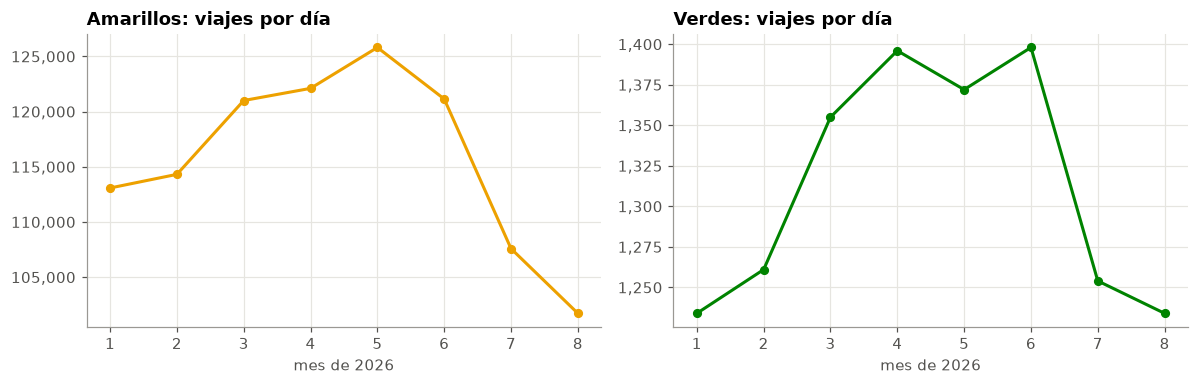

In [3]:
por_mes = ejecutar(con, q, "viajes_por_mes")
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.6))
for eje, tipo in zip(ejes, ["yellow", "green"]):
    datos = por_mes[por_mes.tipo_taxi == tipo]
    eje.plot(datos.mes, datos.viajes_por_dia, color=COLORES[tipo], marker="o", markersize=5)
    eje.set_title(f"{NOMBRES[tipo]}: viajes por día")
    eje.set_xlabel("mes de 2026")
    eje.set_xticks(range(1, 9))
    miles(eje)
plt.tight_layout()
por_mes

**Resultado.** Mayo es el mes más alto para amarillos con 125,810 viajes por día y agosto el más bajo con 101,723, una caída de 19 %. Los verdes se mueven en un rango más estrecho, entre 1,234 y 1,398 viajes por día, con su punto alto en abril y junio.

**Objetivo.** Ver en qué hora y día se concentran los viajes. El conteo se pasa a porcentaje del total de cada tipo para poder comparar.

SELECT
    tipo_taxi,
    isodow(inicio) AS dia_semana,
    hour(inicio) AS hora,
    count(*) AS viajes
FROM viajes_validos
GROUP BY ALL
ORDER BY tipo_taxi, dia_semana, hora;



[viajes_por_hora_y_dia] 336 filas en 0.62 s


tipo_taxi,green,yellow
dia_semana,,
1,45616,3344274
2,48358,3836214
3,50168,4088583
4,52841,4446112
5,47861,4209077
6,38114,4488494
7,36054,3730667


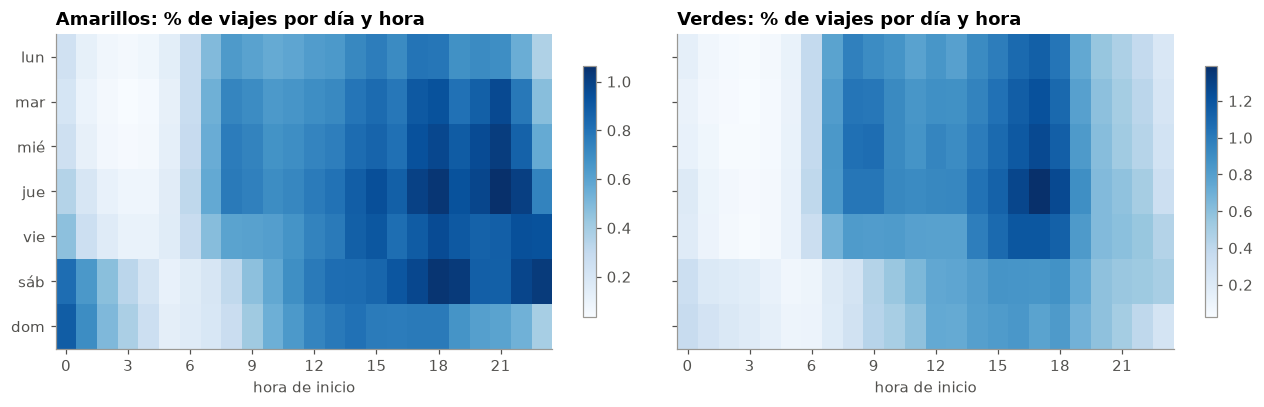

In [4]:
hora_dia = ejecutar(con, q, "viajes_por_hora_y_dia")
dias = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
fig, ejes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for eje, tipo in zip(ejes, ["yellow", "green"]):
    tabla = hora_dia[hora_dia.tipo_taxi == tipo].pivot(index="dia_semana", columns="hora", values="viajes")
    tabla = 100 * tabla / tabla.values.sum()
    imagen = eje.imshow(tabla, aspect="auto", cmap="Blues")
    eje.set_title(f"{NOMBRES[tipo]}: % de viajes por día y hora")
    eje.set_yticks(range(7), dias)
    eje.set_xticks(range(0, 24, 3))
    eje.set_xlabel("hora de inicio")
    eje.grid(False)
    fig.colorbar(imagen, ax=eje, shrink=0.8)
plt.tight_layout()
resumen_hora = hora_dia.groupby(["tipo_taxi", "hora"]).viajes.sum().unstack(0)
resumen_dia = hora_dia.groupby(["tipo_taxi", "dia_semana"]).viajes.sum().unstack(0)
resumen_dia

**Resultado.** Los amarillos tienen su pico a las 18 h y mantienen mucha actividad hasta las 22 h. El sábado es su día más fuerte (4.49 millones de viajes). Los verdes alcanzan el pico a las 17 h, caen rápido después de las 19 h y su día más bajo es el domingo (36,054 contra 52,841 del jueves). Los verdes sirven más a viajes de día laboral y los amarillos también a la vida nocturna de fin de semana.

## P2. Características de los viajes

**Objetivo.** Describir el viaje típico con medianas y percentil 90, que son más estables que el promedio ante los valores extremos vistos en el Ejercicio 3.

In [5]:
ejecutar(con, q, "caracteristicas_viaje")

SELECT
    tipo_taxi,
    round(median(trip_distance), 2) AS distancia_mediana_mi,
    round(quantile_cont(trip_distance, 0.9), 2) AS distancia_p90_mi,
    round(median(duracion_min), 1) AS duracion_mediana_min,
    round(quantile_cont(duracion_min, 0.9), 1) AS duracion_p90_min,
    round(median(trip_distance / (duracion_min / 60)), 1) AS velocidad_mediana_mph,
    round(avg(passenger_count), 2) AS pasajeros_promedio,
    round(100.0 * count(*) FILTER (WHERE passenger_count = 1) / count(passenger_count), 1) AS pct_un_pasajero
FROM viajes_validos
GROUP BY tipo_taxi
ORDER BY tipo_taxi;



[caracteristicas_viaje] 2 filas en 4.59 s


,tipo_taxi,distancia_mediana_mi,distancia_p90_mi,duracion_mediana_min,duracion_p90_min,velocidad_mediana_mph,pasajeros_promedio,pct_un_pasajero
0,green,2.16,7.53,13.4,32.7,10.0,1.30,82.9
1,yellow,1.94,8.70,14.2,33.5,9.3,1.25,82.3


**Resultado.** El viaje típico es corto y lento. La mediana es de 1.94 millas y 14.2 minutos en amarillos y 2.16 millas y 13.4 minutos en verdes, con una velocidad mediana cercana a 10 mph. El 82 % de los viajes con dato de pasajeros lleva a una sola persona.

## P3. Amarillos contra verdes por zona

**Objetivo.** Ver dónde recogen pasajeros los dos tipos. Se une con la tabla de zonas de la TLC (`data/raw/taxi_zone_lookup.csv`).

In [6]:
ejecutar(con, q, "viajes_por_distrito")

SELECT
    v.tipo_taxi,
    z.distrito,
    count(*) AS viajes,
    round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY v.tipo_taxi), 2) AS pct
FROM viajes_validos v
JOIN zonas z ON z.location_id = v.PULocationID
GROUP BY v.tipo_taxi, z.distrito
ORDER BY v.tipo_taxi, viajes DESC;



[viajes_por_distrito] 15 filas en 0.64 s


,tipo_taxi,distrito,viajes,pct
0,green,Manhattan,190988,59.87
1,green,Queens,69536,21.80
2,green,Brooklyn,50151,15.72
3,green,Bronx,7836,2.46
4,green,Unknown,286,0.09
5,green,N/A,165,0.05
6,green,Staten Island,50,0.02
7,yellow,Manhattan,24413067,86.75
8,yellow,Queens,2462523,8.75
9,yellow,Brooklyn,1013689,3.60


In [7]:
ejecutar(con, q, "zonas_de_recogida")

WITH conteo AS (
    SELECT tipo_taxi, PULocationID, count(*) AS viajes
    FROM viajes_validos
    GROUP BY ALL
)
SELECT
    c.tipo_taxi,
    z.distrito,
    z.zona,
    c.viajes,
    round(100.0 * c.viajes / sum(c.viajes) OVER (PARTITION BY c.tipo_taxi), 2) AS pct
FROM conteo c
JOIN zonas z ON z.location_id = c.PULocationID
QUALIFY row_number() OVER (PARTITION BY c.tipo_taxi ORDER BY c.viajes DESC) <= 8
ORDER BY c.tipo_taxi, c.viajes DESC;



[zonas_de_recogida] 16 filas en 0.60 s


,tipo_taxi,distrito,zona,viajes,pct
0,green,Manhattan,East Harlem North,86767,27.20
1,green,Manhattan,East Harlem South,41697,13.07
2,green,Queens,Forest Hills,15569,4.88
3,green,Manhattan,Central Park,12966,4.06
4,green,Manhattan,Morningside Heights,12430,3.90
5,green,Queens,Elmhurst,10990,3.45
6,green,Manhattan,Central Harlem,10946,3.43
7,green,Brooklyn,Downtown Brooklyn/MetroTech,10475,3.28
8,yellow,Manhattan,Upper East Side South,1250744,4.44
9,yellow,Manhattan,Midtown Center,1169726,4.16


**Resultado.** Los amarillos son un servicio de Manhattan, donde inician el 86.75 % de sus viajes, más el aeropuerto JFK (3.95 %). Los verdes están mucho más concentrados en pocos barrios. East Harlem North y South suman el 40.27 % de sus recogidas y Queens y Brooklyn aportan el 37.5 %. Esto coincide con su regla de operación, que les impide recoger en el centro de Manhattan.

## P4. Pago

**Objetivo.** Distribución de la forma de pago.

In [8]:
ejecutar(con, q, "tipos_de_pago")

SELECT
    tipo_taxi,
    CASE coalesce(payment_type, 0)
        WHEN 0 THEN 'Flex / sin dato'
        WHEN 1 THEN 'Tarjeta'
        WHEN 2 THEN 'Efectivo'
        WHEN 3 THEN 'Sin cargo'
        WHEN 4 THEN 'Disputa'
        WHEN 5 THEN 'Desconocido'
        WHEN 6 THEN 'Viaje anulado'
    END AS tipo_pago,
    count(*) AS viajes,
    round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo_taxi), 2) AS pct
FROM viajes_validos
GROUP BY tipo_taxi, payment_type
ORDER BY tipo_taxi, viajes DESC;



[tipos_de_pago] 10 filas en 0.56 s


,tipo_taxi,tipo_pago,viajes,pct
0,green,Tarjeta,209543,65.68
1,green,Efectivo,61563,19.30
2,green,Flex / sin dato,47229,14.80
3,green,Sin cargo,479,0.15
4,green,Disputa,198,0.06
5,yellow,Tarjeta,18407887,65.41
6,yellow,Flex / sin dato,7038011,25.01
7,yellow,Efectivo,2531598,9.00
8,yellow,Disputa,112579,0.40
9,yellow,Sin cargo,53346,0.19


**Resultado.** Dos de cada tres viajes se pagan con tarjeta en ambos tipos (65.41 % y 65.68 %). La diferencia está en el resto. Los verdes usan más efectivo (19.30 % contra 9.00 %) y en los amarillos el 25.01 % no tiene forma de pago registrada, que son los mismos registros con nulos en bloque del Ejercicio 3.

**Objetivo.** Medir la propina solo en pagos con tarjeta, porque las propinas en efectivo no se registran y bajarían el promedio de forma artificial.

In [9]:
ejecutar(con, q, "propinas_tarjeta")

-- Las propinas en efectivo no se registran, por eso solo se usa pago con tarjeta.
SELECT
    tipo_taxi,
    count(*) AS viajes_tarjeta,
    round(avg(tip_amount), 2) AS propina_promedio,
    round(median(100 * tip_amount / fare_amount), 1) AS propina_mediana_pct,
    round(100.0 * count(*) FILTER (WHERE tip_amount = 0) / count(*), 1) AS pct_sin_propina
FROM viajes_validos
WHERE payment_type = 1 AND fare_amount > 0
GROUP BY tipo_taxi
ORDER BY tipo_taxi;



[propinas_tarjeta] 2 filas en 0.94 s


,tipo_taxi,viajes_tarjeta,propina_promedio,propina_mediana_pct,pct_sin_propina
0,green,209542,3.79,23.6,8.3
1,yellow,18407854,4.24,26.4,8.8


**Resultado.** La propina mediana es 26.4 % de la tarifa en amarillos y 23.6 % en verdes, y menos del 9 % de los pagos con tarjeta no deja propina.

**Objetivo.** Ver qué compone el cobro promedio.

In [10]:
ejecutar(con, q, "composicion_del_cobro")

SELECT
    tipo_taxi,
    round(avg(total_amount), 2) AS total,
    round(avg(fare_amount), 2) AS tarifa,
    round(avg(tip_amount), 2) AS propina,
    round(avg(tolls_amount), 2) AS peajes,
    round(avg(coalesce(congestion_surcharge, 0)), 2) AS recargo_congestion,
    round(avg(coalesce(cbd_congestion_fee, 0)), 2) AS cargo_cbd,
    round(avg(coalesce(airport_fee, 0)), 2) AS cargo_aeropuerto,
    round(avg(extra + mta_tax + improvement_surcharge), 2) AS otros
FROM viajes_validos
GROUP BY tipo_taxi
ORDER BY tipo_taxi;



[composicion_del_cobro] 2 filas en 0.63 s


,tipo_taxi,total,tarifa,propina,peajes,recargo_congestion,cargo_cbd,cargo_aeropuerto,otros
0,green,25.36,16.67,2.60,0.30,0.79,0.06,0.00,2.32
1,yellow,30.18,21.23,2.88,0.55,1.70,0.54,0.13,2.64


**Resultado.** Un viaje amarillo cuesta en promedio 30.18 dólares contra 25.36 de uno verde. La diferencia no es solo la tarifa. Los amarillos pagan en promedio 1.70 de recargo por congestión y 0.54 de cargo por entrar al distrito central (CBD), mientras que los verdes pagan 0.79 y 0.06 porque casi no circulan por esa zona.

## P5. Distribución del monto y atípicos

**Objetivo.** Distribución del monto total en rangos de 10 dólares, con todo lo mayor a 150 en el último rango.

SELECT
    tipo_taxi,
    least(floor(total_amount / 10) * 10, 150) AS rango_total_usd,
    count(*) AS viajes,
    round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo_taxi), 2) AS pct
FROM viajes_validos
GROUP BY tipo_taxi, rango_total_usd
ORDER BY tipo_taxi, rango_total_usd;



[distribucion_total] 32 filas en 0.58 s


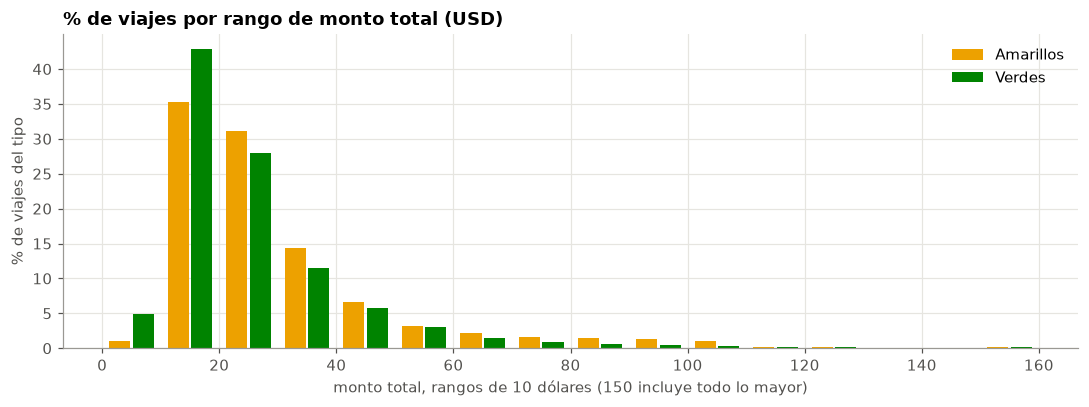

In [11]:
distribucion = ejecutar(con, q, "distribucion_total")
fig, eje = plt.subplots(figsize=(10, 3.8))
ancho = 4
for desplazamiento, tipo in [(-ancho / 2, "yellow"), (ancho / 2, "green")]:
    datos = distribucion[distribucion.tipo_taxi == tipo]
    eje.bar(datos.rango_total_usd + 5 + desplazamiento, datos.pct, width=ancho - 0.4, color=COLORES[tipo], label=NOMBRES[tipo])
eje.set_title("% de viajes por rango de monto total (USD)")
eje.set_xlabel("monto total, rangos de 10 dólares (150 incluye todo lo mayor)")
eje.set_ylabel("% de viajes del tipo")
eje.legend()
plt.tight_layout()

In [12]:
ejecutar(con, q, "tarifa_por_tipo_de_tarifa")

SELECT
    tipo_taxi,
    RatecodeID,
    count(*) AS viajes,
    round(median(trip_distance), 2) AS distancia_mediana,
    round(median(total_amount), 2) AS total_mediano
FROM viajes_validos
GROUP BY ALL
ORDER BY tipo_taxi, viajes DESC;



[tarifa_por_tipo_de_tarifa] 14 filas en 1.78 s


,tipo_taxi,RatecodeID,viajes,distancia_mediana,total_mediano
0,green,1,260715,1.92,19.50
1,green,<NA>,47229,5.01,26.65
2,green,5,10039,5.30,53.00
3,green,2,576,17.60,94.75
4,green,4,341,14.81,88.01
5,green,3,112,21.30,133.74
6,yellow,1,19429662,1.59,21.06
7,yellow,<NA>,7038011,2.90,28.99
8,yellow,99,759682,6.70,32.00
9,yellow,2,652996,17.80,97.15


In [13]:
ejecutar(con, q, "atipicos")

SELECT
    tipo_taxi,
    count(*) AS validos,
    count(*) FILTER (WHERE trip_distance / (duracion_min / 60) > 60) AS velocidad_mayor_60mph,
    count(*) FILTER (WHERE fare_amount / trip_distance > 50 AND trip_distance > 0.5) AS tarifa_por_milla_mayor_50,
    count(*) FILTER (WHERE total_amount > 300) AS total_mayor_300,
    count(*) FILTER (WHERE tip_amount > fare_amount AND fare_amount > 0) AS propina_mayor_que_tarifa,
    count(*) FILTER (WHERE passenger_count > 6) AS mas_de_6_pasajeros
FROM viajes_validos
GROUP BY tipo_taxi
ORDER BY tipo_taxi;



[atipicos] 2 filas en 0.59 s


,tipo_taxi,validos,velocidad_mayor_60mph,tarifa_por_milla_mayor_50,total_mayor_300,propina_mayor_que_tarifa,mas_de_6_pasajeros
0,green,319012,123,138,39,523,59
1,yellow,28143421,6631,18637,4325,27624,8


In [14]:
ejecutar(con, q, "limites_iqr")

WITH cuartiles AS (
    SELECT
        tipo_taxi,
        quantile_cont(total_amount, 0.25) AS q1,
        quantile_cont(total_amount, 0.75) AS q3
    FROM viajes_validos
    GROUP BY tipo_taxi
)
SELECT
    c.tipo_taxi,
    round(c.q1, 2) AS q1,
    round(c.q3, 2) AS q3,
    round(c.q3 + 1.5 * (c.q3 - c.q1), 2) AS limite_superior,
    count(*) FILTER (WHERE v.total_amount > c.q3 + 1.5 * (c.q3 - c.q1)) AS atipicos,
    round(100.0 * atipicos / count(*), 2) AS pct_atipicos
FROM viajes_validos v
JOIN cuartiles c USING (tipo_taxi)
GROUP BY c.tipo_taxi, c.q1, c.q3
ORDER BY c.tipo_taxi;



[limites_iqr] 2 filas en 2.58 s


,tipo_taxi,q1,q3,limite_superior,atipicos,pct_atipicos
0,green,15.19,29.70,51.47,20732,6.50
1,yellow,17.53,34.45,59.83,2383103,8.47


**Resultado.** El 66.4 % de los amarillos y el 70.8 % de los verdes cuesta entre 10 y 30 dólares. Los amarillos tienen una cola más pesada entre 60 y 110 dólares, que corresponde a los viajes a aeropuertos con tarifa fija (`RatecodeID = 2`, mediana de 97.15 dólares). Por eso el criterio de rango intercuartílico marca como atípico el 8.47 % de los amarillos (más de 59.83 dólares), aunque muchos de esos viajes son legítimos.

Los atípicos reales son menos. Hay 6,631 viajes amarillos con velocidad mayor a 60 mph, 18,637 con más de 50 dólares por milla y 27,624 con propina mayor que la tarifa. Juntos son menos del 0.2 % de los viajes válidos.

## 4.5 Hallazgos

**Los verdes dependen de pocos barrios.** El 40.27 % de sus recogidas sale de East Harlem, mientras que la zona más usada por los amarillos solo concentra el 4.44 %.

**Un cuarto de los viajes amarillos no trae datos del taxímetro.** El 25.01 % de los viajes válidos no tiene forma de pago, pasajeros ni tipo de tarifa. Cualquier indicador que use esas columnas debe aclarar que se calcula sobre el resto.

**Los dos servicios tienen ritmos distintos.** Los amarillos tienen su día más fuerte el sábado y mucha actividad nocturna. Los verdes caen 32 % del jueves al domingo y casi no operan de noche.

**La demanda baja en verano.** Los amarillos pasan de 125,810 viajes por día en mayo a 101,723 en agosto.

**El rango intercuartílico sobreestima los atípicos.** Los viajes al aeropuerto con tarifa fija caen fuera del límite aunque son normales, así que conviene separar por `RatecodeID` antes de buscar valores extremos.